In [7]:
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt 
username = "manikya.pant"

In [8]:
class PCA():
    def __init__(self, ncomponents=2):
        self.ncomponents = ncomponents
        self.mean = None
        self.components = None
        self.eigenvalues = None
    
    def fit(self, X):
        # mean centering
        self.mean = np.mean(X, axis=0)
        X = X - self.mean

        # covariance matrix
        cov = np.cov(X, rowvar=False)

        # eigenvalues and eigenvectors
        eigenvalues, eigenvectors = np.linalg.eigh(cov)

        # sort eigenvalues and corresponding eigenvectors
        idxs = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idxs]
        eigenvectors = eigenvectors[:, idxs]

        # store the eigenvalues and the first ncomponents of eigenvectors
        self.eigenvalues = eigenvalues
        self.components = eigenvectors[:, :self.ncomponents]
    

    def transform(self, X):
        X = X - self.mean
        return np.dot(X, self.components)
    
    def checkPcA(self, X):
        # check if the covariance matrix is diagonal
        X = X - self.mean
        X_pca = np.dot(X, self.components)
        cov = np.cov(X_pca, rowvar=False)
        return np.allclose(cov, np.diag(np.diag(cov)))
    

    def explained_variance(self):
        return np.sum(self.eigenvalues[:self.ncomponents], axis=0)
    
    def explained_variance_ratio(self):
        total_variance = np.sum(self.eigenvalues)
        return self.explained_variance() / total_variance
    

In [9]:
# loading the mnist dataset and balanced subset of 1000 samples
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X = np.concatenate((X_train, X_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)
X = X.reshape(X.shape[0], -1)
X_balanced = []
y_balanced = []
# taking random 100 samples from each class to make it balanced
for i in range(10):
    idxs = np.where(y == i)[0]
    np.random.shuffle(idxs)
    idxs = idxs[:100]
    X_balanced.append(X[idxs])
    y_balanced.append(y[idxs])
X_balanced = np.concatenate(X_balanced, axis=0)
y_balanced = np.concatenate(y_balanced, axis=0)





3473654.7324822783
3447910.8215316213
3333531.011196283
2582067.131282316


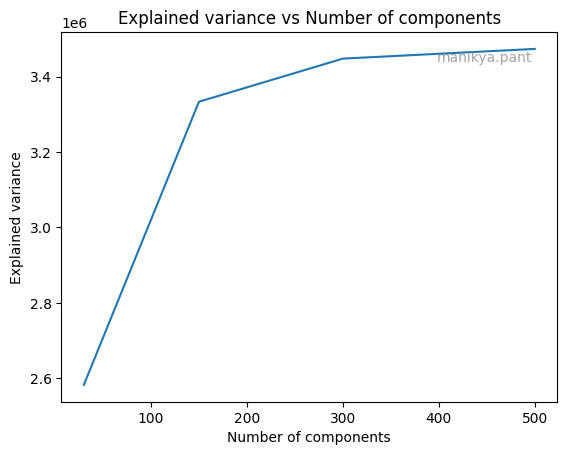

In [10]:
def pcaOnMnist(X, Y , ncomponents=2):
    pca = PCA(ncomponents=ncomponents)
    pca.fit(X)
    # print("Shape of original data:", X.shape)
    # print("Shape of transformed data:", X_pca.shape)
    # print("Explained variance:", pca.explained_variance())
    # print("Explained variance ratio:", pca.explained_variance_ratio())
    # print("Covariance matrix is diagonal:", pca.checkPcA(X))
    # explained_variance = pca.explained_variance()
    print(pca.explained_variance())
    return pca.explained_variance()

# pcaOnMnist(X, y, ncomponents=10)

dim = [500, 300 , 150 , 30]
variance= []
for d in dim:
    variance.append(pcaOnMnist(X_balanced, y_balanced, ncomponents=d))
plt.plot(dim, variance)
plt.xlabel('Number of components')
plt.ylabel('Explained variance')
plt.title('Explained variance vs Number of components')
plt.text(
    0.95, 0.95, username,
    ha='right', va='top',
    transform=plt.gca().transAxes,
    fontsize=10, color='gray', alpha=0.7
)
plt.show()

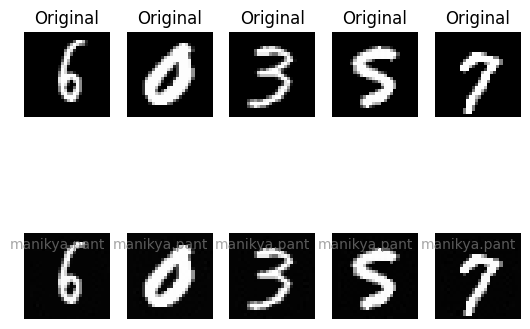

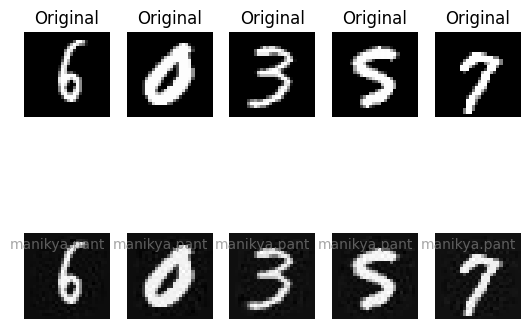

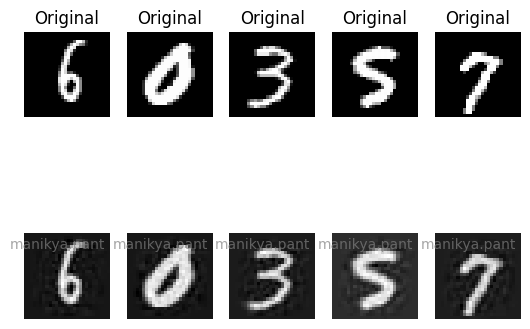

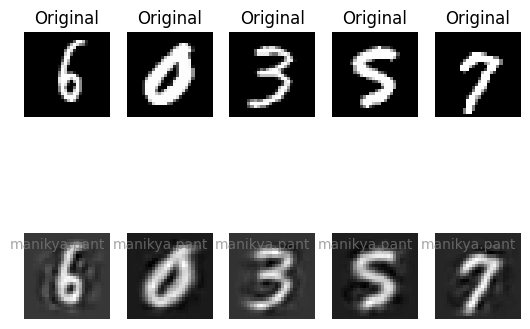

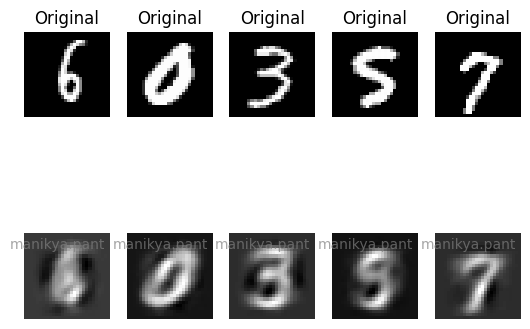

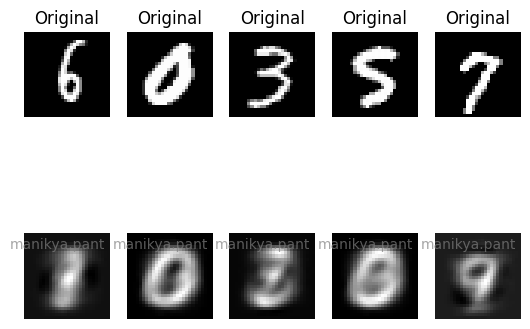

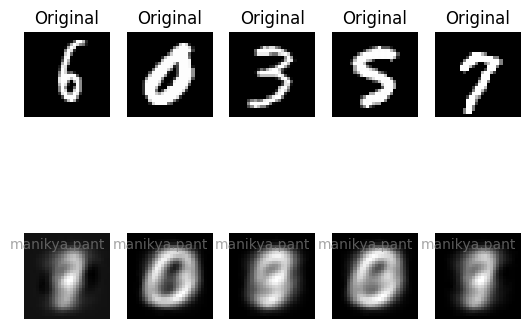

In [11]:
# taking random 5 images from the balanced dataset and plotting them
idxs = np.random.choice(X_balanced.shape[0], 5, replace=False)
images=[X_balanced[idx].reshape(28, 28) for idx in idxs]


dim = [500, 300 , 150 , 50, 10 ,2 , 1]
def X_reconstructed(X, img, ndim):
    pca = PCA(ncomponents=ndim)
    pca.fit(X)
    # Reshape the image to be a single sample in a 2D array
    img_reshaped = img.reshape(1, -1)
    X_pca = pca.transform(img_reshaped)
    # taking the transform data back to original dimension
    X_inv = np.dot(X_pca, pca.components.T) + pca.mean
    return X_inv

for d in dim:
    # pca = PCA(X,ncomponents=d)
    for i in range(5):

        # pca.fit(images[i].reshape(1, -1))
        plt.subplot(2, 5, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.axis('off')
        plt.title('Original')
        plt.subplot(2, 5, i+6)
        plt.imshow(X_reconstructed(X_balanced,images[i], d).reshape(28, 28), cmap='gray')
        plt.axis('off')
        plt.text(
    0.95, 0.95, username,
    ha='right', va='top',
    transform=plt.gca().transAxes,
    fontsize=10, color='gray', alpha=0.7
)
    plt.show()